# Лабораторная работа №4
## Обучение с учителем. Решающие деревья. Ансамбли моделей

**Датасеты:**  
- Классификация: `filtered_diabetes_health_indicators.csv` — статус диабета (`Diabetes_012`: 0/1/2)  
- Регрессия: `filtered_moldova_cars_task.csv` — цена автомобиля (`Price(euro)`)


## 1. Импорт библиотек

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt

from scipy.stats import randint, uniform

# sklearn — разделение, оценка
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold,
    cross_validate, GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Деревья и ансамбли
from sklearn.tree import (
    DecisionTreeClassifier, DecisionTreeRegressor,
    export_text, plot_tree
)
from sklearn.ensemble import (
    RandomForestClassifier, BaggingClassifier,
    GradientBoostingClassifier, StackingClassifier,
    RandomForestRegressor, BaggingRegressor,
    GradientBoostingRegressor, StackingRegressor
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVR

# Градиентный бустинг
from catboost import CatBoostClassifier, CatBoostRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor

# Метрики классификации
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, classification_report
)
# Метрики регрессии
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error, r2_score
)

# Балансировка классов
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Библиотеки загружены')

Библиотеки загружены


## 2. Вспомогательные функции

In [3]:
# ── Классификация: функция метрик ──────────────────────────────────────────
def clf_metrics(y_true, y_pred, average='macro'):
    """Печатает метрики классификации."""
    print(f'Accuracy : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision: {precision_score(y_true, y_pred, average=average, zero_division=0):.4f}')
    print(f'Recall   : {recall_score(y_true, y_pred, average=average, zero_division=0):.4f}')
    print(f'F1       : {f1_score(y_true, y_pred, average=average, zero_division=0):.4f}')

def clf_metrics_dict(y_true, y_pred, average='macro'):
    """Возвращает словарь метрик классификации."""
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average=average, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, average=average, zero_division=0),
        'F1'       : f1_score(y_true, y_pred, average=average, zero_division=0),
    }

# ── Регрессия: функция метрик ───────────────────────────────────────────────
def reg_metrics(y_true, y_pred):
    """Печатает метрики регрессии."""
    print(f'MAE  = {mean_absolute_error(y_true, y_pred):.4f}')
    print(f'MSE  = {mean_squared_error(y_true, y_pred):.4f}')
    print(f'RMSE = {sqrt(mean_squared_error(y_true, y_pred)):.4f}')
    print(f'MAPE = {mean_absolute_percentage_error(y_true, y_pred):.4f}')
    print(f'R²   = {r2_score(y_true, y_pred):.4f}')

def reg_metrics_dict(y_true, y_pred):
    """Возвращает словарь метрик регрессии."""
    return {
        'MAE' : mean_absolute_error(y_true, y_pred),
        'MSE' : mean_squared_error(y_true, y_pred),
        'RMSE': sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred),
        'R2'  : r2_score(y_true, y_pred),
    }

# ── Pipeline helper ─────────────────────────────────────────────────────────
def make_clf_pipeline(model, balance=True):
    """Создаёт Pipeline для классификации: StandardScaler + (балансировка) + модель."""
    steps = [('scaler', StandardScaler())]
    if balance:
        steps.append(('sampler', RandomUnderSampler(sampling_strategy='auto', random_state=42)))
    steps.append(('model', model))
    return ImbPipeline(steps)

def make_reg_pipeline(model):
    """Создаёт Pipeline для регрессии: StandardScaler + модель."""
    return Pipeline([('scaler', StandardScaler()), ('model', model)])

print('Вспомогательные функции определены')

Вспомогательные функции определены


## 3. Собственная реализация CART

In [4]:
from collections import Counter
from abc import ABC, abstractmethod

class TaskStrategy(ABC):
    @abstractmethod
    def compute_metric(self, y): pass
    @abstractmethod
    def compute_value(self, y): pass

class ClassificationStrategy(TaskStrategy):
    def compute_metric(self, y):
        counter = Counter(y)
        impurity = 1.0
        for count in counter.values():
            prob = count / len(y)
            impurity -= prob ** 2
        return impurity
    def compute_value(self, y):
        return Counter(y).most_common(1)[0][0]

class RegressionStrategy(TaskStrategy):
    def compute_metric(self, y):
        if len(y) == 0:
            return 0
        mean = np.mean(y)
        return np.mean((y - mean) ** 2)
    def compute_value(self, y):
        return np.mean(y)

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature   = feature
        self.threshold = threshold
        self.left      = left
        self.right     = right
        self.value     = value

class CART:
    """Собственная реализация дерева CART (классификация и регрессия)."""
    def __init__(self, task_type='classification', max_depth=None, min_samples_split=2):
        if task_type == 'classification':
            self.strategy = ClassificationStrategy()
        else:
            self.strategy = RegressionStrategy()
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.root              = None

    def _split_score(self, left_y, right_y):
        n = len(left_y) + len(right_y)
        return (len(left_y) * self.strategy.compute_metric(left_y) +
                len(right_y) * self.strategy.compute_metric(right_y)) / n

    def _best_split(self, X, y):
        best_feature, best_threshold, best_score = None, None, float('inf')
        for feature in range(X.shape[1]):
            for threshold in np.unique(X[:, feature]):
                mask = X[:, feature] <= threshold
                left_y, right_y = y[mask], y[~mask]
                if len(left_y) < self.min_samples_split or len(right_y) < self.min_samples_split:
                    continue
                score = self._split_score(left_y, right_y)
                if score < best_score:
                    best_score, best_feature, best_threshold = score, feature, threshold
        return best_feature, best_threshold, best_score

    def _build_tree(self, X, y, depth=0):
        if (self.max_depth is not None and depth >= self.max_depth) or len(y) < self.min_samples_split:
            return Node(value=self.strategy.compute_value(y))
        feature, threshold, _ = self._best_split(X, y)
        if feature is None:
            return Node(value=self.strategy.compute_value(y))
        mask = X[:, feature] <= threshold
        return Node(
            feature=feature, threshold=threshold,
            left =self._build_tree(X[mask],  y[mask],  depth+1),
            right=self._build_tree(X[~mask], y[~mask], depth+1)
        )

    def fit(self, X, y):
        if isinstance(X, pd.DataFrame): X = X.to_numpy()
        if isinstance(y, (pd.Series, pd.DataFrame)): y = y.to_numpy()
        self.root = self._build_tree(X, y)
        return self

    def _predict_one(self, x, node):
        if node.value is not None:
            return node.value
        return self._predict_one(x, node.left if x[node.feature] <= node.threshold else node.right)

    def predict(self, X):
        if isinstance(X, pd.DataFrame): X = X.to_numpy()
        return np.array([self._predict_one(x, self.root) for x in X])

print('CART реализован')

CART реализован


---
# ЧАСТЬ I. КЛАССИФИКАЦИЯ
**Датасет:** `filtered_diabetes_health_indicators.csv`  
**Целевая переменная:** `Diabetes_012` (0 — нет диабета, 1 — предиабет, 2 — диабет 2 типа)  
**Тип задачи:** мультиклассовая классификация (3 класса)


## 4. Загрузка и подготовка данных (Классификация)

In [5]:
data_cl = pd.read_csv('../datasets/filtered_diabetes_health_indicators.csv')
print(f'Размер датасета: {data_cl.shape}')
data_cl.head()

Размер датасета: (229718, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,1,0,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,0,0,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,0,0,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,1,0,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,1,0,1,0,2,3,0,0,0,11,5,4


Распределение классов:
Diabetes_012
0    189994
2     35095
1      4629
Name: count, dtype: int64


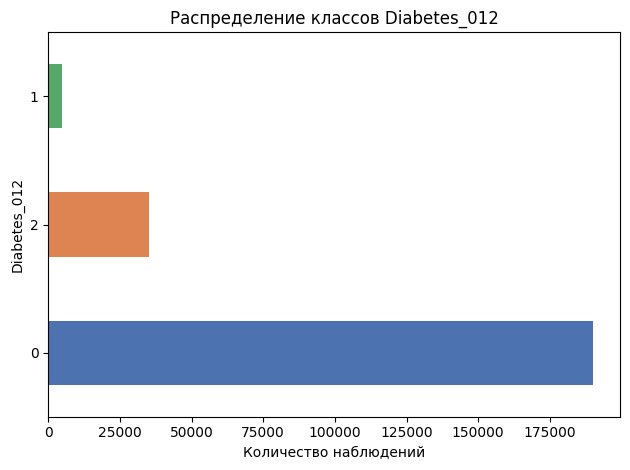

In [6]:
X_cl = data_cl.drop(columns=['Diabetes_012'])
y_cl = data_cl['Diabetes_012']

print('Распределение классов:')
print(y_cl.value_counts())

y_cl.value_counts().plot.barh(color=['#4C72B0','#DD8452','#55A868'])
plt.title('Распределение классов Diabetes_012')
plt.xlabel('Количество наблюдений')
plt.tight_layout()
plt.show()

### 4.1. Hold-out разделение

In [7]:
X_train_cl, X_test_cl, y_train_cl, y_test_cl = train_test_split(
    X_cl, y_cl,
    test_size=0.2,
    random_state=42,
    stratify=y_cl
)
print(f'Train: {X_train_cl.shape}, Test: {X_test_cl.shape}')

Train: (183774, 21), Test: (45944, 21)


### 4.2. K-fold (StratifiedKFold, k=5)

In [8]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('StratifiedKFold(n_splits=5) определён')

StratifiedKFold(n_splits=5) определён


## 5. Поиск гиперпараметров (Классификация)

In [9]:
# Параметры для поиска (компактные сетки для разумного времени)
param_grids_cl = {
    'DecisionTreeClassifier': {
        'GridSearchCV': {
            'model__criterion'       : ['gini', 'entropy'],
            'model__max_depth'       : [5, 10, None],
            'model__min_samples_leaf': [1, 5],
            'model__class_weight'    : [None, 'balanced']
        },
        'RandomizedSearchCV': {
            'model__criterion'        : ['gini', 'entropy'],
            'model__max_depth'        : randint(3, 20),
            'model__min_samples_split': randint(2, 30),
            'model__min_samples_leaf' : randint(1, 15),
            'model__class_weight'     : [None, 'balanced'],
        }
    },
    'RandomForestClassifier': {
        'RandomizedSearchCV': {
            'model__n_estimators'     : randint(50, 200),
            'model__max_depth'        : randint(5, 20),
            'model__min_samples_split': randint(2, 10),
            'model__min_samples_leaf' : randint(1, 5),
            'model__criterion'        : ['gini', 'entropy'],
        }
    },
    'GradientBoostingClassifier': {
        'RandomizedSearchCV': {
            'model__n_estimators'  : randint(50, 150),
            'model__learning_rate' : uniform(0.05, 0.15),
            'model__max_depth'     : randint(2, 5),
            'model__subsample'     : uniform(0.7, 0.3),
        }
    },
    'BaggingClassifier': {
        'GridSearchCV': {
            'model__n_estimators': [10, 50],
            'model__max_samples' : [0.7, 1.0],
            'model__max_features': [0.7, 1.0],
            'model__bootstrap'   : [True],
        }
    },
    'CatBoostClassifier': {
        'GridSearchCV': {
            'model__iterations'   : [100, 200],
            'model__depth'        : [4, 6],
            'model__learning_rate': [0.05, 0.1],
        }
    },
    'XGBClassifier': {
        'GridSearchCV': {
            'model__n_estimators'  : [100, 200],
            'model__max_depth'     : [3, 6],
            'model__learning_rate' : [0.05, 0.1],
            'model__subsample'     : [0.8, 1.0],
        }
    },
    'LGBMClassifier': {
        'GridSearchCV': {
            'model__n_estimators'  : [100, 200],
            'model__learning_rate' : [0.05, 0.1],
            'model__num_leaves'    : [31, 63],
        }
    },
}
print('Параметры для поиска определены')

Параметры для поиска определены


In [10]:
import json, os

def convert(o):
    if isinstance(o, np.generic): return o.item()
    raise TypeError

def run_search_cl(model_name, method, model_obj, param_grid, X_tr, y_tr, cv, n_iter=20, scoring='f1_macro'):
    from sklearn.model_selection import train_test_split as tts
    if len(X_tr) > 10000:
        X_s, _, y_s, _ = tts(X_tr, y_tr, train_size=10000, stratify=y_tr, random_state=42)
    else:
        X_s, y_s = X_tr, y_tr
    
    if method == 'GridSearchCV':
        n_fits = 1
        for v in param_grid.values():
            n_fits *= len(v)
        n_fits *= 3  # cv=3
        print(f'  GridSearchCV: {n_fits} fits запланировано (cv=3)')
        search = GridSearchCV(
            make_clf_pipeline(model_obj), param_grid,
            cv=3, scoring=scoring, n_jobs=-1, verbose=2
        )
    else:
        n_fits = n_iter * 3
        print(f'  RandomizedSearchCV: {n_fits} fits запланировано (n_iter={n_iter}, cv=3)')
        search = RandomizedSearchCV(
            make_clf_pipeline(model_obj), param_grid,
            n_iter=n_iter, cv=3, scoring=scoring,
            n_jobs=-1, random_state=42, verbose=2
        )
    search.fit(X_s, y_s)
    return search.best_params_, search.best_score_

# Кэш гиперпараметров
cl_params_file = 'best_params_cl.json'
if os.path.exists(cl_params_file):
    with open(cl_params_file) as f:
        best_cl = json.load(f)
else:
    best_cl = {}
print('Кэш загружен:', list(best_cl.keys()))

Кэш загружен: ['LogisticRegression', 'kNN', 'NaiveBayes', 'SVM', 'DecisionTreeClassifier_GridSearchCV', 'DecisionTreeClassifier_RandomizedSearchCV', 'RandomForestClassifier_RandomizedSearchCV', 'GradientBoostingClassifier_RandomizedSearchCV', 'BaggingClassifier_GridSearchCV', 'CatBoostClassifier_GridSearchCV', 'XGBClassifier_GridSearchCV', 'LGBMClassifier_GridSearchCV']


### 5.1. DecisionTreeClassifier — GridSearchCV и RandomizedSearchCV

In [11]:
from sklearn.tree import DecisionTreeClassifier

for method, pg in param_grids_cl['DecisionTreeClassifier'].items():
    key = f'DecisionTreeClassifier_{method}'
    if key in best_cl:
        print(f'[кэш] {key}: score={best_cl[key]["score"]:.4f}')
        continue
    print(f'Поиск {key}...')
    params, score = run_search_cl(
        'DT', method, DecisionTreeClassifier(random_state=42),
        pg, X_train_cl, y_train_cl, cv=skf, n_iter=30
    )
    best_cl[key] = {'params': params, 'score': score}
    with open(cl_params_file, 'w') as f: json.dump(best_cl, f, indent=2, default=convert)
    print(f'  best score={score:.4f}, params={params}')

[кэш] DecisionTreeClassifier_GridSearchCV: score=0.3999
[кэш] DecisionTreeClassifier_RandomizedSearchCV: score=0.3998


### 5.2. RandomForestClassifier — RandomizedSearchCV

In [12]:
key = 'RandomForestClassifier_RandomizedSearchCV'
if key not in best_cl:
    print(f'Поиск {key}...')
    params, score = run_search_cl(
        'RF', 'RandomizedSearchCV', RandomForestClassifier(random_state=42, n_jobs=2),
        param_grids_cl['RandomForestClassifier']['RandomizedSearchCV'],
        X_train_cl, y_train_cl, cv=skf, n_iter=20
    )
    best_cl[key] = {'params': params, 'score': score}
    with open(cl_params_file, 'w') as f: json.dump(best_cl, f, indent=2, default=convert)
    print(f'  best score={score:.4f}')
else:
    print(f'[кэш] {key}: score={best_cl[key]["score"]:.4f}')

[кэш] RandomForestClassifier_RandomizedSearchCV: score=0.4239


### 5.3. GradientBoostingClassifier — RandomizedSearchCV

In [13]:
key = 'GradientBoostingClassifier_RandomizedSearchCV'
if key not in best_cl:
    print(f'Поиск {key}...')
    params, score = run_search_cl(
        'GB', 'RandomizedSearchCV', GradientBoostingClassifier(random_state=42),
        param_grids_cl['GradientBoostingClassifier']['RandomizedSearchCV'],
        X_train_cl, y_train_cl, cv=skf, n_iter=20
    )
    best_cl[key] = {'params': params, 'score': score}
    with open(cl_params_file, 'w') as f: json.dump(best_cl, f, indent=2, default=convert)
    print(f'  best score={score:.4f}')
else:
    print(f'[кэш] {key}: score={best_cl[key]["score"]:.4f}')

[кэш] GradientBoostingClassifier_RandomizedSearchCV: score=0.4180


### 5.4. BaggingClassifier — GridSearchCV

In [14]:
key = 'BaggingClassifier_GridSearchCV'
if key not in best_cl:
    print(f'Поиск {key}...')
    params, score = run_search_cl(
        'Bag', 'GridSearchCV', BaggingClassifier(random_state=42, n_jobs=2),
        param_grids_cl['BaggingClassifier']['GridSearchCV'],
        X_train_cl, y_train_cl, cv=skf
    )
    best_cl[key] = {'params': params, 'score': score}
    with open(cl_params_file, 'w') as f: json.dump(best_cl, f, indent=2, default=convert)
    print(f'  best score={score:.4f}')
else:
    print(f'[кэш] {key}: score={best_cl[key]["score"]:.4f}')

[кэш] BaggingClassifier_GridSearchCV: score=0.4068


### 5.5. CatBoostClassifier — GridSearchCV

In [15]:
key = 'CatBoostClassifier_GridSearchCV'
if key not in best_cl:
    print(f'Поиск {key}...')
    params, score = run_search_cl(
        'CB', 'GridSearchCV', CatBoostClassifier(verbose=0, random_state=42),
        param_grids_cl['CatBoostClassifier']['GridSearchCV'],
        X_train_cl, y_train_cl, cv=skf
    )
    best_cl[key] = {'params': params, 'score': score}
    with open(cl_params_file, 'w') as f: json.dump(best_cl, f, indent=2, default=convert)
    print(f'  best score={score:.4f}')
else:
    print(f'[кэш] {key}: score={best_cl[key]["score"]:.4f}')

[кэш] CatBoostClassifier_GridSearchCV: score=0.4197


### 5.6. XGBClassifier — GridSearchCV

In [16]:
key = 'XGBClassifier_GridSearchCV'
if key not in best_cl:
    print(f'Поиск {key}...')
    params, score = run_search_cl(
        'XGB', 'GridSearchCV',
        XGBClassifier(verbosity=0, use_label_encoder=False, eval_metric='mlogloss', random_state=42),
        param_grids_cl['XGBClassifier']['GridSearchCV'],
        X_train_cl, y_train_cl, cv=skf
    )
    best_cl[key] = {'params': params, 'score': score}
    with open(cl_params_file, 'w') as f: json.dump(best_cl, f, indent=2, default=convert)
    print(f'  best score={score:.4f}')
else:
    print(f'[кэш] {key}: score={best_cl[key]["score"]:.4f}')

[кэш] XGBClassifier_GridSearchCV: score=0.4161


### 5.7. LGBMClassifier — GridSearchCV

In [17]:
key = 'LGBMClassifier_GridSearchCV'
if key not in best_cl:
    print(f'Поиск {key}...')
    params, score = run_search_cl(
        'LGBM', 'GridSearchCV', LGBMClassifier(verbose=-1, random_state=42),
        param_grids_cl['LGBMClassifier']['GridSearchCV'],
        X_train_cl, y_train_cl, cv=skf
    )
    best_cl[key] = {'params': params, 'score': score}
    with open(cl_params_file, 'w') as f: json.dump(best_cl, f, indent=2, default=convert)
    print(f'  best score={score:.4f}')
else:
    print(f'[кэш] {key}: score={best_cl[key]["score"]:.4f}')

[кэш] LGBMClassifier_GridSearchCV: score=0.3667


## 6. Обучение классификаторов

### 6.1. CART (собственная реализация)

In [18]:
cart_cl = CART(task_type='classification', max_depth=5)
cart_cl.fit(X_train_cl, y_train_cl)
y_pred_cart_cl = cart_cl.predict(X_test_cl)

print('=== CART (собственная реализация) ===')
clf_metrics(y_test_cl, y_pred_cart_cl)
print()
print(classification_report(y_test_cl, y_pred_cart_cl,
      target_names=['Нет диабета','Предиабет','Диабет']))

=== CART (собственная реализация) ===
Accuracy : 0.8326
Precision: 0.4781
Recall   : 0.3617
F1       : 0.3577

              precision    recall  f1-score   support

 Нет диабета       0.84      0.99      0.91     37999
   Предиабет       0.00      0.00      0.00       926
      Диабет       0.60      0.10      0.17      7019

    accuracy                           0.83     45944
   macro avg       0.48      0.36      0.36     45944
weighted avg       0.78      0.83      0.78     45944



### 6.2. DecisionTreeClassifier (sklearn)

In [19]:
p = best_cl.get('DecisionTreeClassifier_GridSearchCV', {}).get('params', {})

dt_cl = make_clf_pipeline(DecisionTreeClassifier(
    criterion      = p.get('model__criterion', 'gini'),
    max_depth      = p.get('model__max_depth', 10),
    min_samples_leaf = p.get('model__min_samples_leaf', 1),
    class_weight   = p.get('model__class_weight', 'balanced'),
    random_state   = 42
))

# Hold-out
dt_cl.fit(X_train_cl, y_train_cl)
y_pred_dt_cl = dt_cl.predict(X_test_cl)
print('=== DecisionTreeClassifier — Hold-out ===')
clf_metrics(y_test_cl, y_pred_dt_cl)

# K-fold
cv_dt_cl = cross_validate(dt_cl, X_cl, y_cl, cv=skf,
                           scoring=['accuracy','f1_macro','precision_macro','recall_macro'])
print('\n=== DecisionTreeClassifier — K-fold (mean) ===')
for k, v in cv_dt_cl.items():
    if k.startswith('test_'):
        print(f'  {k[5:]}: {v.mean():.4f} ± {v.std():.4f}')

=== DecisionTreeClassifier — Hold-out ===
Accuracy : 0.5933
Precision: 0.4292
Recall   : 0.4891
F1       : 0.4012

=== DecisionTreeClassifier — K-fold (mean) ===
  accuracy: 0.5646 ± 0.0204
  f1_macro: 0.3937 ± 0.0083
  precision_macro: 0.4346 ± 0.0038
  recall_macro: 0.4845 ± 0.0101


### 6.3. RandomForestClassifier

In [20]:
p = best_cl.get('RandomForestClassifier_RandomizedSearchCV', {}).get('params', {})

rf_cl = make_clf_pipeline(RandomForestClassifier(
    n_estimators     = p.get('model__n_estimators', 100),
    max_depth        = p.get('model__max_depth', None),
    min_samples_split = p.get('model__min_samples_split', 2),
    min_samples_leaf  = p.get('model__min_samples_leaf', 1),
    criterion        = p.get('model__criterion', 'gini'),
    random_state     = 42,
    n_jobs           = 2
))

rf_cl.fit(X_train_cl, y_train_cl)
y_pred_rf_cl = rf_cl.predict(X_test_cl)
print('=== RandomForestClassifier — Hold-out ===')
clf_metrics(y_test_cl, y_pred_rf_cl)

cv_rf_cl = cross_validate(rf_cl, X_cl, y_cl, cv=skf,
                           scoring=['accuracy','f1_macro','precision_macro','recall_macro'])
print('\n=== RandomForestClassifier — K-fold (mean) ===')
for k, v in cv_rf_cl.items():
    if k.startswith('test_'):
        print(f'  {k[5:]}: {v.mean():.4f} ± {v.std():.4f}')

=== RandomForestClassifier — Hold-out ===
Accuracy : 0.6522
Precision: 0.4358
Recall   : 0.4990
F1       : 0.4252

=== RandomForestClassifier — K-fold (mean) ===
  accuracy: 0.6412 ± 0.0067
  f1_macro: 0.4228 ± 0.0042
  precision_macro: 0.4362 ± 0.0019
  recall_macro: 0.5023 ± 0.0080


### 6.4. BaggingClassifier

In [21]:
p = best_cl.get('BaggingClassifier_GridSearchCV', {}).get('params', {})

bag_cl = make_clf_pipeline(BaggingClassifier(
    n_estimators = p.get('model__n_estimators', 50),
    max_samples  = p.get('model__max_samples', 1.0),
    max_features = p.get('model__max_features', 1.0),
    bootstrap    = p.get('model__bootstrap', True),
    random_state = 42,
    n_jobs       = 2
))

bag_cl.fit(X_train_cl, y_train_cl)
y_pred_bag_cl = bag_cl.predict(X_test_cl)
print('=== BaggingClassifier — Hold-out ===')
clf_metrics(y_test_cl, y_pred_bag_cl)

cv_bag_cl = cross_validate(bag_cl, X_cl, y_cl, cv=skf,
                            scoring=['accuracy','f1_macro','precision_macro','recall_macro'])
print('\n=== BaggingClassifier — K-fold (mean) ===')
for k, v in cv_bag_cl.items():
    if k.startswith('test_'):
        print(f'  {k[5:]}: {v.mean():.4f} ± {v.std():.4f}')

=== BaggingClassifier — Hold-out ===
Accuracy : 0.5955
Precision: 0.4342
Recall   : 0.4835
F1       : 0.4019

=== BaggingClassifier — K-fold (mean) ===
  accuracy: 0.6007 ± 0.0030
  f1_macro: 0.4069 ± 0.0021
  precision_macro: 0.4360 ± 0.0011
  recall_macro: 0.4969 ± 0.0059


### 6.5. GradientBoostingClassifier

In [22]:
p = best_cl.get('GradientBoostingClassifier_RandomizedSearchCV', {}).get('params', {})

gb_cl = make_clf_pipeline(GradientBoostingClassifier(
    n_estimators  = p.get('model__n_estimators', 100),
    learning_rate = p.get('model__learning_rate', 0.1),
    max_depth     = p.get('model__max_depth', 3),
    subsample     = p.get('model__subsample', 1.0),
    random_state  = 42
))

gb_cl.fit(X_train_cl, y_train_cl)
y_pred_gb_cl = gb_cl.predict(X_test_cl)
print('=== GradientBoostingClassifier — Hold-out ===')
clf_metrics(y_test_cl, y_pred_gb_cl)

cv_gb_cl = cross_validate(gb_cl, X_cl, y_cl, cv=skf,
                           scoring=['accuracy','f1_macro','precision_macro','recall_macro'])
print('\n=== GradientBoostingClassifier — K-fold (mean) ===')
for k, v in cv_gb_cl.items():
    if k.startswith('test_'):
        print(f'  {k[5:]}: {v.mean():.4f} ± {v.std():.4f}')

=== GradientBoostingClassifier — Hold-out ===
Accuracy : 0.6180
Precision: 0.4428
Recall   : 0.5026
F1       : 0.4179

=== GradientBoostingClassifier — K-fold (mean) ===
  accuracy: 0.6133 ± 0.0025
  f1_macro: 0.4175 ± 0.0028
  precision_macro: 0.4428 ± 0.0019
  recall_macro: 0.5095 ± 0.0078


### 6.6. StackingClassifier

In [23]:
base_estimators_cl = [
    ('dt',  DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=7))
]
stack_cl = make_clf_pipeline(
    StackingClassifier(
        estimators=base_estimators_cl,
        final_estimator=LogisticRegression(max_iter=5000, random_state=42),
        n_jobs=2
    )
)

stack_cl.fit(X_train_cl, y_train_cl)
y_pred_stack_cl = stack_cl.predict(X_test_cl)
print('=== StackingClassifier — Hold-out ===')
clf_metrics(y_test_cl, y_pred_stack_cl)

cv_stack_cl = cross_validate(stack_cl, X_cl, y_cl, cv=skf,
                              scoring=['accuracy','f1_macro','precision_macro','recall_macro'])
print('\n=== StackingClassifier — K-fold (mean) ===')
for k, v in cv_stack_cl.items():
    if k.startswith('test_'):
        print(f'  {k[5:]}: {v.mean():.4f} ± {v.std():.4f}')

=== StackingClassifier — Hold-out ===
Accuracy : 0.6054
Precision: 0.4391
Recall   : 0.4982
F1       : 0.4118

=== StackingClassifier — K-fold (mean) ===
  accuracy: 0.5926 ± 0.0134
  f1_macro: 0.4067 ± 0.0043
  precision_macro: 0.4386 ± 0.0010
  recall_macro: 0.4906 ± 0.0040


### 6.7. CatBoostClassifier

In [24]:
p = best_cl.get('CatBoostClassifier_GridSearchCV', {}).get('params', {})

cb_cl = make_clf_pipeline(CatBoostClassifier(
    iterations   = p.get('model__iterations', 200),
    depth        = p.get('model__depth', 6),
    learning_rate = p.get('model__learning_rate', 0.1),
    verbose      = 0,
    random_state = 42
))

cb_cl.fit(X_train_cl, y_train_cl)
y_pred_cb_cl = cb_cl.predict(X_test_cl)
print('=== CatBoostClassifier — Hold-out ===')
clf_metrics(y_test_cl, y_pred_cb_cl)

cv_cb_cl = cross_validate(cb_cl, X_cl, y_cl, cv=skf,
                           scoring=['accuracy','f1_macro','precision_macro','recall_macro'])
print('\n=== CatBoostClassifier — K-fold (mean) ===')
for k, v in cv_cb_cl.items():
    if k.startswith('test_'):
        print(f'  {k[5:]}: {v.mean():.4f} ± {v.std():.4f}')

=== CatBoostClassifier — Hold-out ===
Accuracy : 0.6186
Precision: 0.4477
Recall   : 0.5118
F1       : 0.4222

=== CatBoostClassifier — K-fold (mean) ===
  accuracy: 0.6122 ± 0.0057
  f1_macro: 0.4192 ± 0.0029
  precision_macro: 0.4455 ± 0.0014
  recall_macro: 0.5102 ± 0.0070


### 6.8. XGBClassifier

In [25]:
p = best_cl.get('XGBClassifier_GridSearchCV', {}).get('params', {})

xgb_cl = make_clf_pipeline(XGBClassifier(
    n_estimators  = p.get('model__n_estimators', 100),
    max_depth     = p.get('model__max_depth', 3),
    learning_rate = p.get('model__learning_rate', 0.1),
    subsample     = p.get('model__subsample', 0.8),
    verbosity     = 0,
    eval_metric   = 'mlogloss',
    random_state  = 42
))

xgb_cl.fit(X_train_cl, y_train_cl)
y_pred_xgb_cl = xgb_cl.predict(X_test_cl)
print('=== XGBClassifier — Hold-out ===')
clf_metrics(y_test_cl, y_pred_xgb_cl)

cv_xgb_cl = cross_validate(xgb_cl, X_cl, y_cl, cv=skf,
                            scoring=['accuracy','f1_macro','precision_macro','recall_macro'])
print('\n=== XGBClassifier — K-fold (mean) ===')
for k, v in cv_xgb_cl.items():
    if k.startswith('test_'):
        print(f'  {k[5:]}: {v.mean():.4f} ± {v.std():.4f}')

=== XGBClassifier — Hold-out ===
Accuracy : 0.6103
Precision: 0.4427
Recall   : 0.5026
F1       : 0.4154

=== XGBClassifier — K-fold (mean) ===
  accuracy: 0.6119 ± 0.0012
  f1_macro: 0.4169 ± 0.0017
  precision_macro: 0.4417 ± 0.0014
  recall_macro: 0.5109 ± 0.0071


### 6.9. LGBMClassifier

In [26]:
p = best_cl.get('LGBMClassifier_GridSearchCV', {}).get('params', {})

lgbm_cl = make_clf_pipeline(LGBMClassifier(
    n_estimators  = p.get('model__n_estimators', 100),
    learning_rate = p.get('model__learning_rate', 0.1),
    num_leaves    = p.get('model__num_leaves', 31),
    subsample     = p.get('model__subsample', 0.8),
    verbose       = -1,
    random_state  = 42
))

lgbm_cl.fit(X_train_cl, y_train_cl)
y_pred_lgbm_cl = lgbm_cl.predict(X_test_cl)
print('=== LGBMClassifier — Hold-out ===')
clf_metrics(y_test_cl, y_pred_lgbm_cl)

cv_lgbm_cl = cross_validate(lgbm_cl, X_cl, y_cl, cv=skf,
                             scoring=['accuracy','f1_macro','precision_macro','recall_macro'])
print('\n=== LGBMClassifier — K-fold (mean) ===')
for k, v in cv_lgbm_cl.items():
    if k.startswith('test_'):
        print(f'  {k[5:]}: {v.mean():.4f} ± {v.std():.4f}')

=== LGBMClassifier — Hold-out ===
Accuracy : 0.5878
Precision: 0.4431
Recall   : 0.5031
F1       : 0.4078

=== LGBMClassifier — K-fold (mean) ===
  accuracy: 0.5898 ± 0.0072
  f1_macro: 0.4087 ± 0.0033
  precision_macro: 0.4424 ± 0.0013
  recall_macro: 0.5069 ± 0.0085


## 7. Визуализация дерева решений

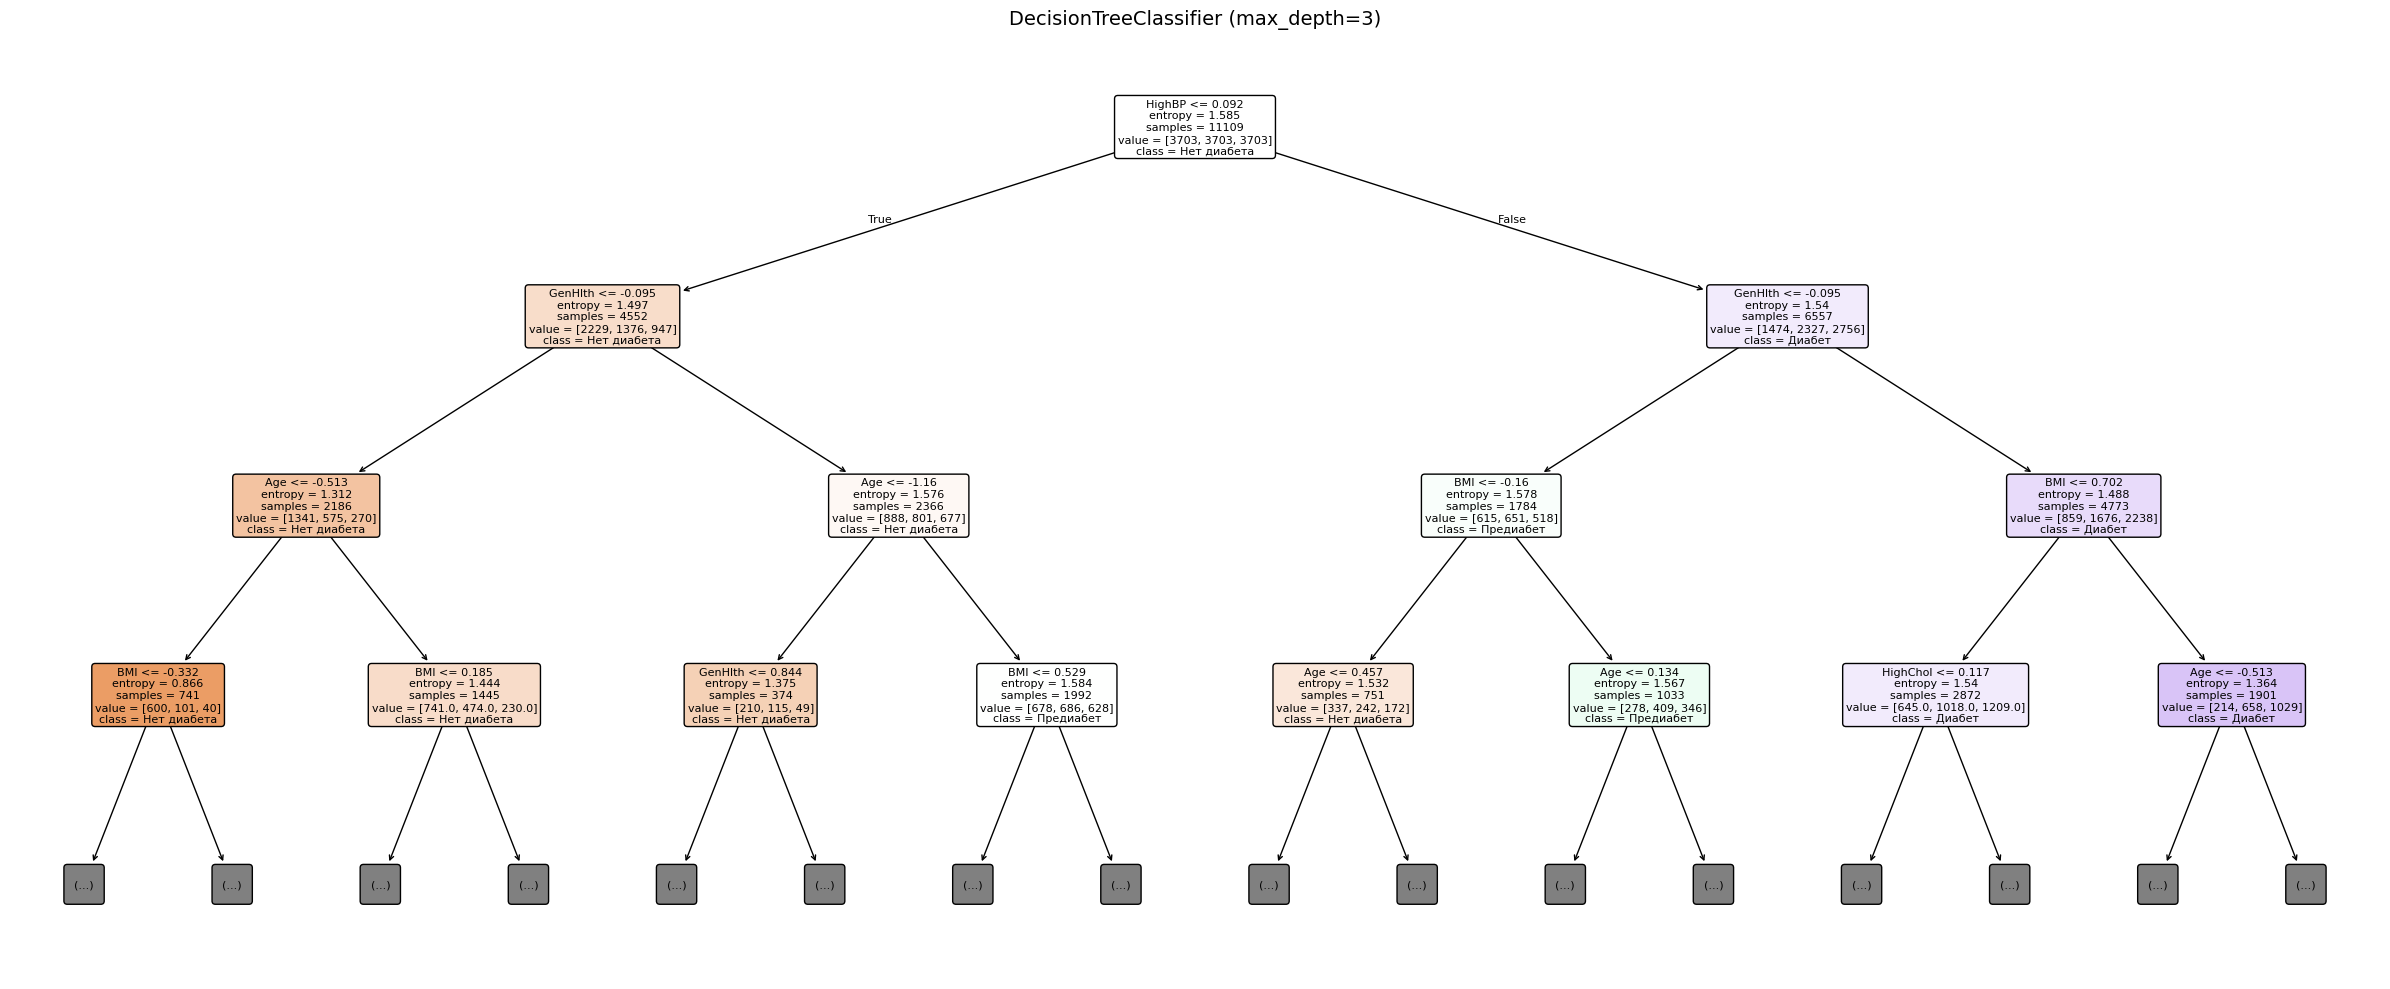

In [27]:
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    dt_cl.named_steps['model'],
    feature_names=X_cl.columns.tolist(),
    class_names=['Нет диабета', 'Предиабет', 'Диабет'],
    filled=True, rounded=True, max_depth=3, fontsize=8, ax=ax
)
plt.title('DecisionTreeClassifier (max_depth=3)', fontsize=14)
plt.tight_layout()
plt.show()

### 7.1. Правила дерева (текстовый вид)

In [28]:
tree_rules = export_text(dt_cl.named_steps['model'],
                          feature_names=X_cl.columns.tolist(),
                          max_depth=4)
print('Решающие правила дерева:')
print(tree_rules)

Решающие правила дерева:
|--- HighBP <= 0.09
|   |--- GenHlth <= -0.10
|   |   |--- Age <= -0.51
|   |   |   |--- BMI <= -0.33
|   |   |   |   |--- PhysHlth <= -0.13
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- PhysHlth >  -0.13
|   |   |   |   |   |--- class: 0
|   |   |   |--- BMI >  -0.33
|   |   |   |   |--- GenHlth <= -1.03
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- GenHlth >  -1.03
|   |   |   |   |   |--- class: 0
|   |   |--- Age >  -0.51
|   |   |   |--- BMI <= 0.18
|   |   |   |   |--- HighChol <= 0.12
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- HighChol >  0.12
|   |   |   |   |   |--- class: 0
|   |   |   |--- BMI >  0.18
|   |   |   |   |--- CholCheck <= -2.33
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- CholCheck >  -2.33
|   |   |   |   |   |--- class: 1
|   |--- GenHlth >  -0.10
|   |   |--- Age <= -1.16
|   |   |   |--- GenHlth <= 0.84
|   |   |   |   |--- HighChol <= 0.12
|   |   |   |   |   |--- class: 0
|   |   |   |   |---

## 8. Матрицы ошибок

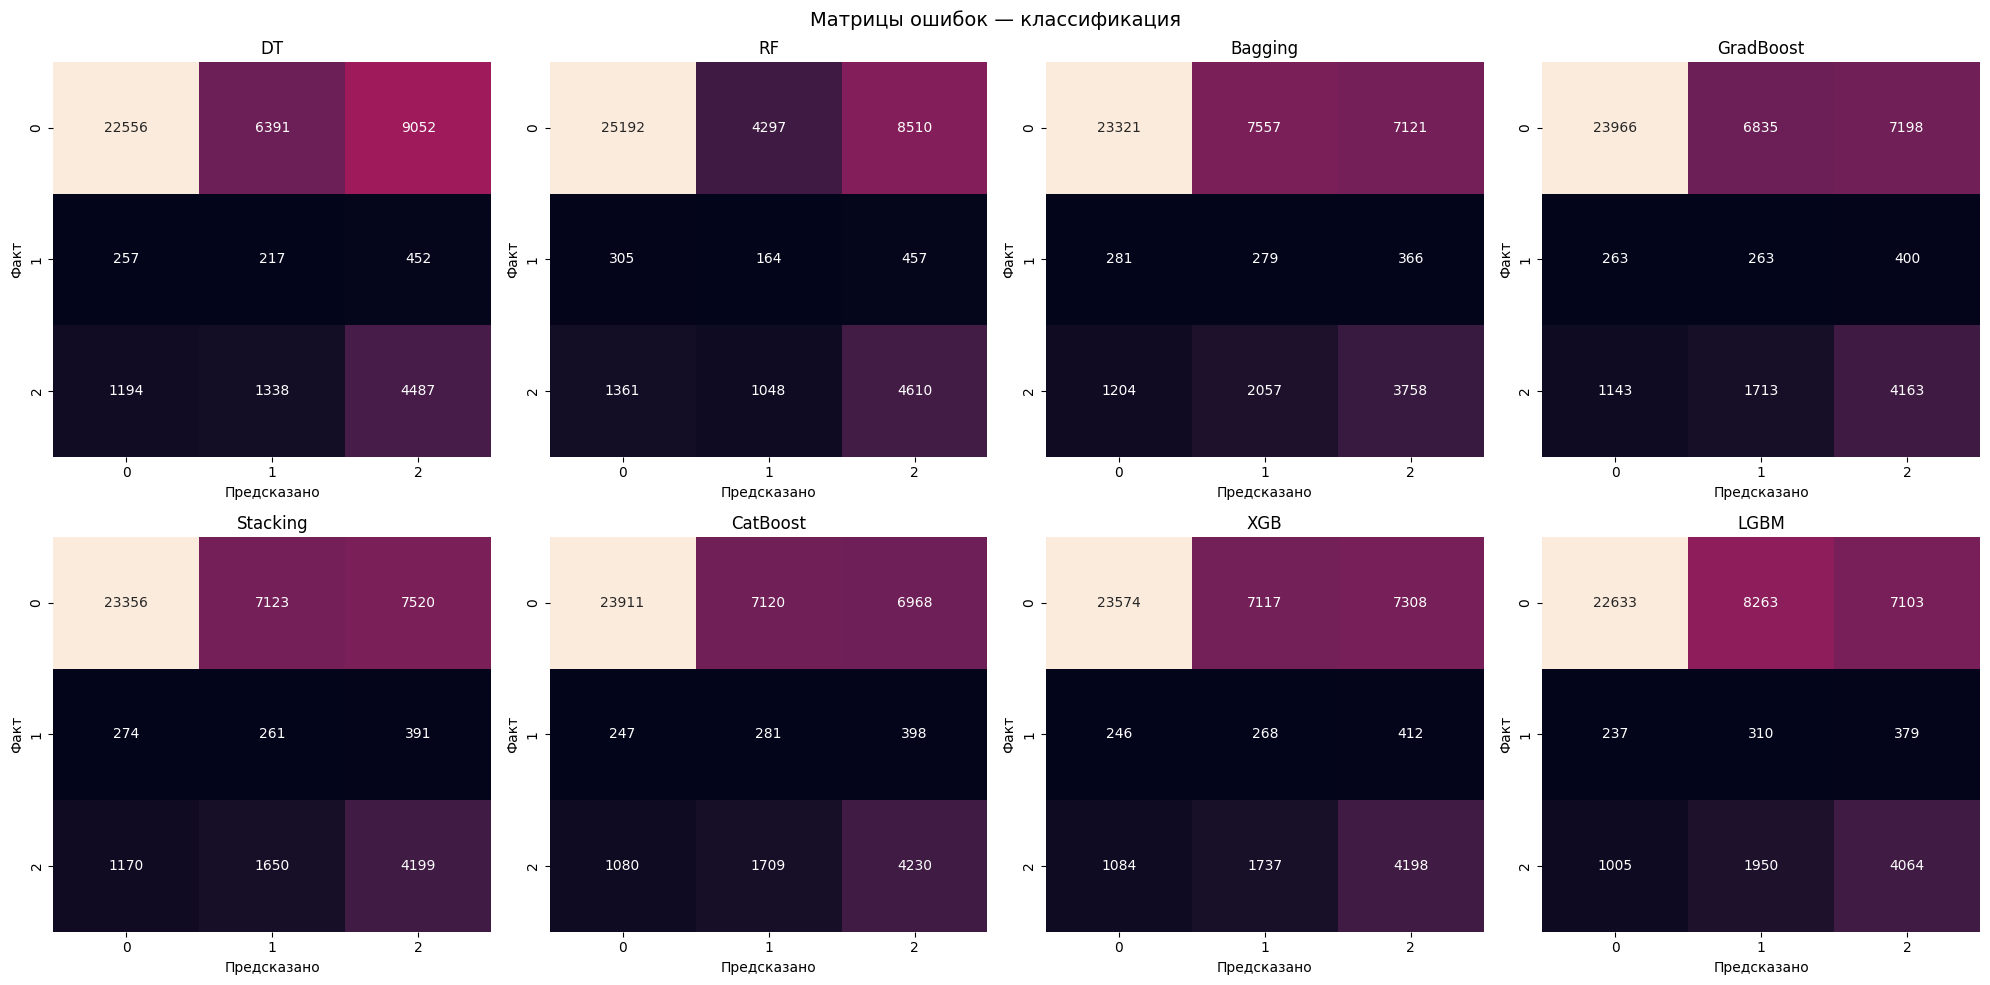

In [29]:
names_cl   = ['DT', 'RF', 'Bagging', 'GradBoost', 'Stacking', 'CatBoost', 'XGB', 'LGBM']
preds_cl   = [y_pred_dt_cl, y_pred_rf_cl, y_pred_bag_cl, y_pred_gb_cl,
               y_pred_stack_cl, y_pred_cb_cl, y_pred_xgb_cl, y_pred_lgbm_cl]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, name, pred in zip(axes.flat, names_cl, preds_cl):
    cm = confusion_matrix(y_test_cl, pred)
    sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=ax,
                xticklabels=['0','1','2'], yticklabels=['0','1','2'])
    ax.set_title(name)
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Факт')
plt.suptitle('Матрицы ошибок — классификация', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Таблица результатов — Классификация

In [30]:
# Hold-out результаты
models_info_cl = [
    ('CART (собств.)', y_pred_cart_cl),
    ('DecisionTree',   y_pred_dt_cl),
    ('RandomForest',   y_pred_rf_cl),
    ('Bagging',        y_pred_bag_cl),
    ('GradientBoosting', y_pred_gb_cl),
    ('Stacking',       y_pred_stack_cl),
    ('CatBoost',       y_pred_cb_cl),
    ('XGBoost',        y_pred_xgb_cl),
    ('LightGBM',       y_pred_lgbm_cl),
]

rows_ho = []
for name, pred in models_info_cl:
    m = clf_metrics_dict(y_test_cl, pred)
    rows_ho.append({'Алгоритм': name, **m})

df_ho_cl = pd.DataFrame(rows_ho).set_index('Алгоритм')
print('=== Hold-out ===')
display(df_ho_cl.round(4))

=== Hold-out ===


,Accuracy,Precision,Recall,F1
Алгоритм,,,,
CART (собств.),0.8326,0.4781,0.3617,0.3577
DecisionTree,0.5933,0.4292,0.4891,0.4012
RandomForest,0.6522,0.4358,0.4990,0.4252
Bagging,0.5955,0.4342,0.4835,0.4019
GradientBoosting,0.6180,0.4428,0.5026,0.4179
Stacking,0.6054,0.4391,0.4982,0.4118
CatBoost,0.6186,0.4477,0.5118,0.4222
XGBoost,0.6103,0.4427,0.5026,0.4154
LightGBM,0.5878,0.4431,0.5031,0.4078


In [31]:
# K-fold результаты
cv_results_cl = {
    'DecisionTree'     : cv_dt_cl,
    'RandomForest'     : cv_rf_cl,
    'Bagging'          : cv_bag_cl,
    'GradientBoosting' : cv_gb_cl,
    'Stacking'         : cv_stack_cl,
    'CatBoost'         : cv_cb_cl,
    'XGBoost'          : cv_xgb_cl,
    'LightGBM'         : cv_lgbm_cl,
}

rows_kf = []
for name, cv in cv_results_cl.items():
    rows_kf.append({
        'Алгоритм' : name,
        'Accuracy' : cv['test_accuracy'].mean(),
        'Precision': cv['test_precision_macro'].mean(),
        'Recall'   : cv['test_recall_macro'].mean(),
        'F1'       : cv['test_f1_macro'].mean(),
    })

df_kf_cl = pd.DataFrame(rows_kf).set_index('Алгоритм')
print('=== K-fold (mean) ===')
display(df_kf_cl.round(4))

=== K-fold (mean) ===


,Accuracy,Precision,Recall,F1
Алгоритм,,,,
DecisionTree,0.5646,0.4346,0.4845,0.3937
RandomForest,0.6412,0.4362,0.5023,0.4228
Bagging,0.6007,0.4360,0.4969,0.4069
GradientBoosting,0.6133,0.4428,0.5095,0.4175
Stacking,0.5926,0.4386,0.4906,0.4067
CatBoost,0.6122,0.4455,0.5102,0.4192
XGBoost,0.6119,0.4417,0.5109,0.4169
LightGBM,0.5898,0.4424,0.5069,0.4087


In [32]:
# Сводная таблица (Образец 2)
df_summary_cl = df_ho_cl.copy()
df_summary_cl.columns = pd.MultiIndex.from_product([['Hold-out'], df_ho_cl.columns])

df_kf2 = df_kf_cl.copy()
df_kf2.columns = pd.MultiIndex.from_product([['K-fold'], df_kf2.columns])

df_both_cl = pd.concat([df_summary_cl, df_kf2], axis=1)
print('=== Сводная таблица — Классификация ===')
display(df_both_cl.round(4))

=== Сводная таблица — Классификация ===


Hold-out                           K-fold                   \
                 Accuracy Precision Recall     F1 Accuracy Precision Recall   
Алгоритм                                                                      
CART (собств.)     0.8326    0.4781 0.3617 0.3577      NaN       NaN    NaN   
DecisionTree       0.5933    0.4292 0.4891 0.4012   0.5646    0.4346 0.4845   
RandomForest       0.6522    0.4358 0.4990 0.4252   0.6412    0.4362 0.5023   
Bagging            0.5955    0.4342 0.4835 0.4019   0.6007    0.4360 0.4969   
GradientBoosting   0.6180    0.4428 0.5026 0.4179   0.6133    0.4428 0.5095   
Stacking           0.6054    0.4391 0.4982 0.4118   0.5926    0.4386 0.4906   
CatBoost           0.6186    0.4477 0.5118 0.4222   0.6122    0.4455 0.5102   
XGBoost            0.6103    0.4427 0.5026 0.4154   0.6119    0.4417 0.5109   
LightGBM           0.5878    0.4431 0.5031 0.4078   0.5898    0.4424 0.5069   

                         
                     F1  
Алгоритм                 
CART (собств.)      NaN  
DecisionTree     0.3937  
RandomForest     0.4228  
Bagging          0.4069  
GradientBoosting 0.4175  
Stacking         0.4067  
CatBoost         0.4192  
XGBoost          0.4169  
LightGBM         0.4087

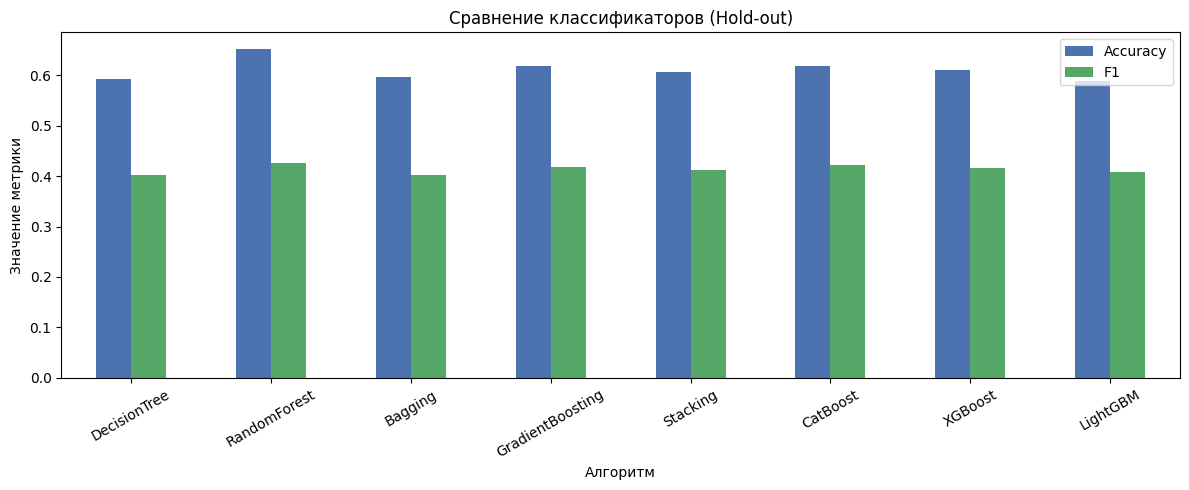

In [33]:
df_ho_cl.drop(index='CART (собств.)', errors='ignore')[['Accuracy','F1']].plot(
    kind='bar', figsize=(12, 5), rot=30, color=['#4C72B0','#55A868']
)
plt.title('Сравнение классификаторов (Hold-out)')
plt.ylabel('Значение метрики')
plt.tight_layout()
plt.show()

---
# ЧАСТЬ II. РЕГРЕССИЯ
**Датасет:** `filtered_moldova_cars_task.csv`  
**Целевая переменная:** `Price(euro)` — цена автомобиля


## 10. Загрузка и подготовка данных (Регрессия)

In [34]:
data_r = pd.read_csv('../datasets/filtered_moldova_cars_task.csv')
print(f'Размер датасета: {data_r.shape}')
data_r.head()

Размер датасета: (27137, 11)


,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission,Price(euro),Vehicle_age,Avg_mileage
0,67,467,2011,4,195000,1800,2,0,7750,15,13000
1,55,315,2014,11,135000,1500,0,1,8550,12,11250
2,55,370,2012,11,110000,1500,0,1,6550,14,7857
3,51,123,2006,11,200000,1600,3,1,4100,20,10000
4,45,629,2000,5,300000,2200,0,1,3490,26,11538


Признаки: 10
Целевая переменная: min=500, max=23333, mean=7466.2


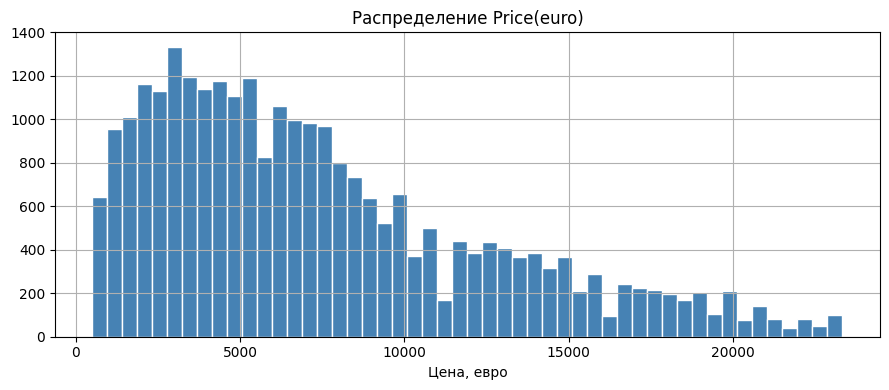

In [35]:
X_r = data_r.drop(columns=['Price(euro)'])
y_r = data_r['Price(euro)']

print(f'Признаки: {X_r.shape[1]}')
print(f'Целевая переменная: min={y_r.min()}, max={y_r.max()}, mean={y_r.mean():.1f}')

y_r.hist(bins=50, figsize=(9,4), color='steelblue', edgecolor='white')
plt.title('Распределение Price(euro)')
plt.xlabel('Цена, евро')
plt.tight_layout()
plt.show()

### 10.1. Hold-out разделение

In [36]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42
)
print(f'Train: {X_train_r.shape}, Test: {X_test_r.shape}')

Train: (21709, 10), Test: (5428, 10)


### 10.2. K-fold (KFold, k=5)

In [37]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print('KFold(n_splits=5) определён')

KFold(n_splits=5) определён


## 11. Поиск гиперпараметров (Регрессия)

In [38]:
param_grids_r = {
    'DecisionTreeRegressor': {
        'GridSearchCV': {
            'model__criterion'       : ['squared_error', 'absolute_error'],
            'model__max_depth'       : [5, 10, None],
            'model__min_samples_leaf': [1, 5, 10],
            'model__min_samples_split': [2, 5, 10],
        },
        'RandomizedSearchCV': {
            'model__criterion'       : ['squared_error', 'absolute_error'],
            'model__max_depth'       : randint(3, 30),
            'model__min_samples_split': randint(2, 50),
            'model__min_samples_leaf': randint(1, 20),
        }
    },
    'RandomForestRegressor': {
        'RandomizedSearchCV': {
            'model__n_estimators'    : randint(50, 300),
            'model__max_depth'       : randint(5, 30),
            'model__min_samples_split': randint(2, 20),
            'model__min_samples_leaf': randint(1, 10),
        }
    },
    'GradientBoostingRegressor': {
        'GridSearchCV': {
            'model__n_estimators'  : [50, 100, 150],
            'model__learning_rate' : [0.05, 0.1, 0.2],
            'model__max_depth'     : [3, 5, 7],
        }
    },
    'BaggingRegressor': {
        'GridSearchCV': {
            'model__n_estimators': [10, 50, 100],
            'model__max_samples' : [0.5, 1.0],
            'model__max_features': [0.5, 1.0],
            'model__bootstrap'   : [True, False],
        }
    },
    'CatBoostRegressor': {
        'GridSearchCV': {
            'model__iterations'   : [100, 200],
            'model__depth'        : [4, 6, 8],
            'model__learning_rate': [0.05, 0.1],
        }
    },
    'XGBRegressor': {
        'GridSearchCV': {
            'model__n_estimators'  : [100, 200],
            'model__max_depth'     : [3, 6],
            'model__learning_rate' : [0.05, 0.1],
            'model__subsample'     : [0.8, 1.0],
        }
    },
    'LGBMRegressor': {
        'GridSearchCV': {
            'model__n_estimators'  : [100, 200],
            'model__learning_rate' : [0.05, 0.1],
            'model__num_leaves'    : [31, 63],
            'model__subsample'     : [0.8, 1.0],
        }
    },
}
print('Параметры для поиска (регрессия) определены')

Параметры для поиска (регрессия) определены


In [39]:
def run_search_r(method, model_obj, param_grid, X_tr, y_tr, cv, n_iter=20, scoring='r2'):
    # Сэмплируем до 5k строк для ускорения поиска
    from sklearn.model_selection import train_test_split as tts
    if len(X_tr) > 5000:
        X_s, _, y_s, _ = tts(X_tr, y_tr, train_size=5000, random_state=42)
    else:
        X_s, y_s = X_tr, y_tr

    if method == 'GridSearchCV':
        n_fits = 1
        for v in param_grid.values():
            n_fits *= len(v)
        n_fits *= 3  # cv=3
        print(f'  GridSearchCV: {n_fits} fits запланировано (cv=3, train_size={len(X_s)})')
        search = GridSearchCV(
            make_reg_pipeline(model_obj), param_grid,
            cv=3, scoring=scoring, n_jobs=-1, verbose=2
        )
    else:
        n_fits = n_iter * 3
        print(f'  RandomizedSearchCV: {n_fits} fits запланировано (n_iter={n_iter}, cv=3, train_size={len(X_s)})')
        search = RandomizedSearchCV(
            make_reg_pipeline(model_obj), param_grid,
            n_iter=n_iter, cv=3, scoring=scoring,
            n_jobs=-1, random_state=42, verbose=2
        )
    search.fit(X_s, y_s)
    return search.best_params_, search.best_score_

r_params_file = 'best_params_r.json'
if os.path.exists(r_params_file):
    with open(r_params_file) as f:
        best_r = json.load(f)
else:
    best_r = {}
print('Кэш загружен:', list(best_r.keys()))

Кэш загружен: ['DecisionTreeRegressor_GridSearchCV', 'DecisionTreeRegressor_RandomizedSearchCV', 'RandomForestRegressor_RandomizedSearchCV', 'GradientBoostingRegressor_GridSearchCV', 'BaggingRegressor_GridSearchCV', 'CatBoostRegressor_GridSearchCV', 'XGBRegressor_GridSearchCV', 'LGBMRegressor_GridSearchCV']


### 11.1. DecisionTreeRegressor — GridSearchCV и RandomizedSearchCV

In [40]:
for method, pg in param_grids_r['DecisionTreeRegressor'].items():
    key = f'DecisionTreeRegressor_{method}'
    if key in best_r:
        print(f'[кэш] {key}: score={best_r[key]["score"]:.4f}')
        continue
    print(f'Поиск {key}...')
    params, score = run_search_r(
        method, DecisionTreeRegressor(random_state=42),
        pg, X_train_r, y_train_r, cv=kf, n_iter=30
    )
    best_r[key] = {'params': params, 'score': score}
    with open(r_params_file, 'w') as f: json.dump(best_r, f, indent=2, default=convert)
    print(f'  best score={score:.4f}')

[кэш] DecisionTreeRegressor_GridSearchCV: score=0.8075
[кэш] DecisionTreeRegressor_RandomizedSearchCV: score=0.8075


### 11.2. RandomForestRegressor — RandomizedSearchCV

In [41]:
key = 'RandomForestRegressor_RandomizedSearchCV'
if key not in best_r:
    print(f'Поиск {key}...')
    params, score = run_search_r(
        'RandomizedSearchCV', RandomForestRegressor(random_state=42, n_jobs=2),
        param_grids_r['RandomForestRegressor']['RandomizedSearchCV'],
        X_train_r, y_train_r, cv=kf, n_iter=20
    )
    best_r[key] = {'params': params, 'score': score}
    with open(r_params_file, 'w') as f: json.dump(best_r, f, indent=2, default=convert)
    print(f'  best score={score:.4f}')
else:
    print(f'[кэш] {key}: score={best_r[key]["score"]:.4f}')

[кэш] RandomForestRegressor_RandomizedSearchCV: score=0.8475


### 11.3. GradientBoostingRegressor — GridSearchCV

In [42]:
key = 'GradientBoostingRegressor_GridSearchCV'
if key not in best_r:
    print(f'Поиск {key}...')
    params, score = run_search_r(
        'GridSearchCV', GradientBoostingRegressor(random_state=42),
        param_grids_r['GradientBoostingRegressor']['GridSearchCV'],
        X_train_r, y_train_r, cv=kf
    )
    best_r[key] = {'params': params, 'score': score}
    with open(r_params_file, 'w') as f: json.dump(best_r, f, indent=2, default=convert)
    print(f'  best score={score:.4f}')
else:
    print(f'[кэш] {key}: score={best_r[key]["score"]:.4f}')

[кэш] GradientBoostingRegressor_GridSearchCV: score=0.8556


### 11.4. BaggingRegressor — GridSearchCV

In [43]:
key = 'BaggingRegressor_GridSearchCV'
if key not in best_r:
    print(f'Поиск {key}...')
    params, score = run_search_r(
        'GridSearchCV', BaggingRegressor(random_state=42, n_jobs=2),
        param_grids_r['BaggingRegressor']['GridSearchCV'],
        X_train_r, y_train_r, cv=kf
    )
    best_r[key] = {'params': params, 'score': score}
    with open(r_params_file, 'w') as f: json.dump(best_r, f, indent=2, default=convert)
    print(f'  best score={score:.4f}')
else:
    print(f'[кэш] {key}: score={best_r[key]["score"]:.4f}')

[кэш] BaggingRegressor_GridSearchCV: score=0.8477


### 11.5–11.7. CatBoost / XGB / LGBM Regressors

In [44]:
for model_name, model_obj, pg_key in [
    ('CatBoostRegressor', CatBoostRegressor(verbose=0, random_state=42), 'CatBoostRegressor'),
    ('XGBRegressor',      XGBRegressor(verbosity=0, random_state=42),    'XGBRegressor'),
    ('LGBMRegressor',     LGBMRegressor(verbose=-1, random_state=42, n_jobs=1),     'LGBMRegressor'),
]:
    key = f'{model_name}_GridSearchCV'
    if key in best_r:
        print(f'[кэш] {key}: score={best_r[key]["score"]:.4f}')
        continue
    print(f'Поиск {key}...')
    params, score = run_search_r(
        'GridSearchCV', model_obj,
        param_grids_r[pg_key]['GridSearchCV'],
        X_train_r, y_train_r, cv=kf
    )
    best_r[key] = {'params': params, 'score': score}
    with open(r_params_file, 'w') as f: json.dump(best_r, f, indent=2, default=convert)
    print(f'  best score={score:.4f}')

[кэш] CatBoostRegressor_GridSearchCV: score=0.8512
[кэш] XGBRegressor_GridSearchCV: score=0.8558
[кэш] LGBMRegressor_GridSearchCV: score=0.8325


## 12. Обучение регрессоров

### 12.1. CART (собственная реализация)

In [45]:
cart_r = CART(task_type='regression', max_depth=8)
cart_r.fit(X_train_r, y_train_r)
y_pred_cart_r = cart_r.predict(X_test_r)

print('=== CART (собственная реализация) ===')
reg_metrics(y_test_r, y_pred_cart_r)

=== CART (собственная реализация) ===
MAE  = 1552.1227
MSE  = 5109797.9505
RMSE = 2260.4862
MAPE = 0.3295
R²   = 0.8087


### 12.2. DecisionTreeRegressor

In [46]:
p = best_r.get('DecisionTreeRegressor_GridSearchCV', {}).get('params', {})

dt_r = make_reg_pipeline(DecisionTreeRegressor(
    criterion        = p.get('model__criterion', 'squared_error'),
    max_depth        = p.get('model__max_depth', 10),
    min_samples_leaf = p.get('model__min_samples_leaf', 1),
    min_samples_split = p.get('model__min_samples_split', 2),
    random_state     = 42
))

dt_r.fit(X_train_r, y_train_r)
y_pred_dt_r = dt_r.predict(X_test_r)
print('=== DecisionTreeRegressor — Hold-out ===')
reg_metrics(y_test_r, y_pred_dt_r)

cv_dt_r = cross_validate(dt_r, X_r, y_r, cv=kf, scoring=['r2','neg_mean_absolute_error'])
print('\n=== DecisionTreeRegressor — K-fold ===')
print(f'  R²  : {cv_dt_r["test_r2"].mean():.4f} ± {cv_dt_r["test_r2"].std():.4f}')
print(f'  MAE : {-cv_dt_r["test_neg_mean_absolute_error"].mean():.4f}')

=== DecisionTreeRegressor — Hold-out ===
MAE  = 1489.8886
MSE  = 4964438.0133
RMSE = 2228.1019
MAPE = 0.3175
R²   = 0.8141

=== DecisionTreeRegressor — K-fold ===
  R²  : 0.8126 ± 0.0034
  MAE : 1491.2838


### 12.3. RandomForestRegressor

In [47]:
p = best_r.get('RandomForestRegressor_RandomizedSearchCV', {}).get('params', {})

rf_r = make_reg_pipeline(RandomForestRegressor(
    n_estimators      = p.get('model__n_estimators', 100),
    max_depth         = p.get('model__max_depth', None),
    min_samples_split = p.get('model__min_samples_split', 2),
    min_samples_leaf  = p.get('model__min_samples_leaf', 1),
    random_state      = 42,
    n_jobs            = 2
))

rf_r.fit(X_train_r, y_train_r)
y_pred_rf_r = rf_r.predict(X_test_r)
print('=== RandomForestRegressor — Hold-out ===')
reg_metrics(y_test_r, y_pred_rf_r)

cv_rf_r = cross_validate(rf_r, X_r, y_r, cv=kf, scoring=['r2','neg_mean_absolute_error'])
print('\n=== RandomForestRegressor — K-fold ===')
print(f'  R²  : {cv_rf_r["test_r2"].mean():.4f} ± {cv_rf_r["test_r2"].std():.4f}')
print(f'  MAE : {-cv_rf_r["test_neg_mean_absolute_error"].mean():.4f}')

=== RandomForestRegressor — Hold-out ===
MAE  = 1259.1538
MSE  = 3791476.1451
RMSE = 1947.1713
MAPE = 0.2784
R²   = 0.8580

=== RandomForestRegressor — K-fold ===
  R²  : 0.8544 ± 0.0032
  MAE : 1264.2456


### 12.4. BaggingRegressor

In [48]:
p = best_r.get('BaggingRegressor_GridSearchCV', {}).get('params', {})

bag_r = make_reg_pipeline(BaggingRegressor(
    n_estimators = p.get('model__n_estimators', 50),
    max_samples  = p.get('model__max_samples', 1.0),
    max_features = p.get('model__max_features', 1.0),
    bootstrap    = p.get('model__bootstrap', True),
    random_state = 42,
    n_jobs       = 2
))

bag_r.fit(X_train_r, y_train_r)
y_pred_bag_r = bag_r.predict(X_test_r)
print('=== BaggingRegressor — Hold-out ===')
reg_metrics(y_test_r, y_pred_bag_r)

cv_bag_r = cross_validate(bag_r, X_r, y_r, cv=kf, scoring=['r2','neg_mean_absolute_error'])
print('\n=== BaggingRegressor — K-fold ===')
print(f'  R²  : {cv_bag_r["test_r2"].mean():.4f} ± {cv_bag_r["test_r2"].std():.4f}')
print(f'  MAE : {-cv_bag_r["test_neg_mean_absolute_error"].mean():.4f}')

=== BaggingRegressor — Hold-out ===
MAE  = 1301.1129
MSE  = 3758058.1550
RMSE = 1938.5712
MAPE = 0.3080
R²   = 0.8593

=== BaggingRegressor — K-fold ===
  R²  : 0.8552 ± 0.0038
  MAE : 1299.1351


### 12.5. GradientBoostingRegressor

In [49]:
p = best_r.get('GradientBoostingRegressor_GridSearchCV', {}).get('params', {})

gb_r = make_reg_pipeline(GradientBoostingRegressor(
    n_estimators  = p.get('model__n_estimators', 100),
    learning_rate = p.get('model__learning_rate', 0.1),
    max_depth     = p.get('model__max_depth', 3),
    random_state  = 42
))

gb_r.fit(X_train_r, y_train_r)
y_pred_gb_r = gb_r.predict(X_test_r)
print('=== GradientBoostingRegressor — Hold-out ===')
reg_metrics(y_test_r, y_pred_gb_r)

cv_gb_r = cross_validate(gb_r, X_r, y_r, cv=kf, scoring=['r2','neg_mean_absolute_error'])
print('\n=== GradientBoostingRegressor — K-fold ===')
print(f'  R²  : {cv_gb_r["test_r2"].mean():.4f} ± {cv_gb_r["test_r2"].std():.4f}')
print(f'  MAE : {-cv_gb_r["test_neg_mean_absolute_error"].mean():.4f}')

=== GradientBoostingRegressor — Hold-out ===
MAE  = 1242.4747
MSE  = 3560839.5592
RMSE = 1887.0187
MAPE = 0.2786
R²   = 0.8667

=== GradientBoostingRegressor — K-fold ===
  R²  : 0.8614 ± 0.0041
  MAE : 1244.0902


### 12.6. StackingRegressor

In [50]:
base_estimators_r = [
    ('dt',  DecisionTreeRegressor(max_depth=8, random_state=42)),
    ('knn', KNeighborsRegressor(n_neighbors=7))
]
stack_r = make_reg_pipeline(
    StackingRegressor(
        estimators=base_estimators_r,
        final_estimator=SVR(),
        n_jobs=2
    )
)

stack_r.fit(X_train_r, y_train_r)
y_pred_stack_r = stack_r.predict(X_test_r)
print('=== StackingRegressor — Hold-out ===')
reg_metrics(y_test_r, y_pred_stack_r)

cv_stack_r = cross_validate(stack_r, X_r, y_r, cv=kf, scoring=['r2','neg_mean_absolute_error'])
print('\n=== StackingRegressor — K-fold ===')
print(f'  R²  : {cv_stack_r["test_r2"].mean():.4f} ± {cv_stack_r["test_r2"].std():.4f}')
print(f'  MAE : {-cv_stack_r["test_neg_mean_absolute_error"].mean():.4f}')

=== StackingRegressor — Hold-out ===
MAE  = 2229.1956
MSE  = 11140051.0049
RMSE = 3337.6715
MAPE = 0.4872
R²   = 0.5829

=== StackingRegressor — K-fold ===
  R²  : 0.5832 ± 0.0027
  MAE : 2226.9753


### 12.7. CatBoostRegressor

In [51]:
p = best_r.get('CatBoostRegressor_GridSearchCV', {}).get('params', {})

cb_r = make_reg_pipeline(CatBoostRegressor(
    iterations    = p.get('model__iterations', 200),
    depth         = p.get('model__depth', 6),
    learning_rate = p.get('model__learning_rate', 0.1),
    verbose       = 0,
    random_state  = 42
))

cb_r.fit(X_train_r, y_train_r)
y_pred_cb_r = cb_r.predict(X_test_r)
print('=== CatBoostRegressor — Hold-out ===')
reg_metrics(y_test_r, y_pred_cb_r)

cv_cb_r = cross_validate(cb_r, X_r, y_r, cv=kf, scoring=['r2','neg_mean_absolute_error'])
print('\n=== CatBoostRegressor — K-fold ===')
print(f'  R²  : {cv_cb_r["test_r2"].mean():.4f} ± {cv_cb_r["test_r2"].std():.4f}')
print(f'  MAE : {-cv_cb_r["test_neg_mean_absolute_error"].mean():.4f}')

=== CatBoostRegressor — Hold-out ===
MAE  = 1285.7137
MSE  = 3681358.0916
RMSE = 1918.6866
MAPE = 0.2785
R²   = 0.8622

=== CatBoostRegressor — K-fold ===
  R²  : 0.8565 ± 0.0040
  MAE : 1295.7000


### 12.8. XGBRegressor

In [52]:
p = best_r.get('XGBRegressor_GridSearchCV', {}).get('params', {})

xgb_r = make_reg_pipeline(XGBRegressor(
    n_estimators  = p.get('model__n_estimators', 100),
    max_depth     = p.get('model__max_depth', 3),
    learning_rate = p.get('model__learning_rate', 0.1),
    subsample     = p.get('model__subsample', 0.8),
    verbosity     = 0,
    random_state  = 42
))

xgb_r.fit(X_train_r, y_train_r)
y_pred_xgb_r = xgb_r.predict(X_test_r)
print('=== XGBRegressor — Hold-out ===')
reg_metrics(y_test_r, y_pred_xgb_r)

cv_xgb_r = cross_validate(xgb_r, X_r, y_r, cv=kf, scoring=['r2','neg_mean_absolute_error'])
print('\n=== XGBRegressor — K-fold ===')
print(f'  R²  : {cv_xgb_r["test_r2"].mean():.4f} ± {cv_xgb_r["test_r2"].std():.4f}')
print(f'  MAE : {-cv_xgb_r["test_neg_mean_absolute_error"].mean():.4f}')

=== XGBRegressor — Hold-out ===
MAE  = 1247.3286
MSE  = 3576418.5000
RMSE = 1891.1421
MAPE = 0.2740
R²   = 0.8661

=== XGBRegressor — K-fold ===
  R²  : 0.8618 ± 0.0036
  MAE : 1249.0052


### 12.9. LGBMRegressor

In [53]:
p = best_r.get('LGBMRegressor_GridSearchCV', {}).get('params', {})

lgbm_r = make_reg_pipeline(LGBMRegressor(
    n_estimators  = p.get('model__n_estimators', 100),
    learning_rate = p.get('model__learning_rate', 0.1),
    num_leaves    = p.get('model__num_leaves', 31),
    subsample     = p.get('model__subsample', 0.8),
    verbose       = -1,
    random_state  = 42
))

lgbm_r.fit(X_train_r, y_train_r)
y_pred_lgbm_r = lgbm_r.predict(X_test_r)
print('=== LGBMRegressor — Hold-out ===')
reg_metrics(y_test_r, y_pred_lgbm_r)

cv_lgbm_r = cross_validate(lgbm_r, X_r, y_r, cv=kf, scoring=['r2','neg_mean_absolute_error'])
print('\n=== LGBMRegressor — K-fold ===')
print(f'  R²  : {cv_lgbm_r["test_r2"].mean():.4f} ± {cv_lgbm_r["test_r2"].std():.4f}')
print(f'  MAE : {-cv_lgbm_r["test_neg_mean_absolute_error"].mean():.4f}')

=== LGBMRegressor — Hold-out ===
MAE  = 1288.0187
MSE  = 3692238.7828
RMSE = 1921.5199
MAPE = 0.2827
R²   = 0.8618

=== LGBMRegressor — K-fold ===
  R²  : 0.8576 ± 0.0034
  MAE : 1290.8192


## 13. Визуализация дерева решений (Регрессия)

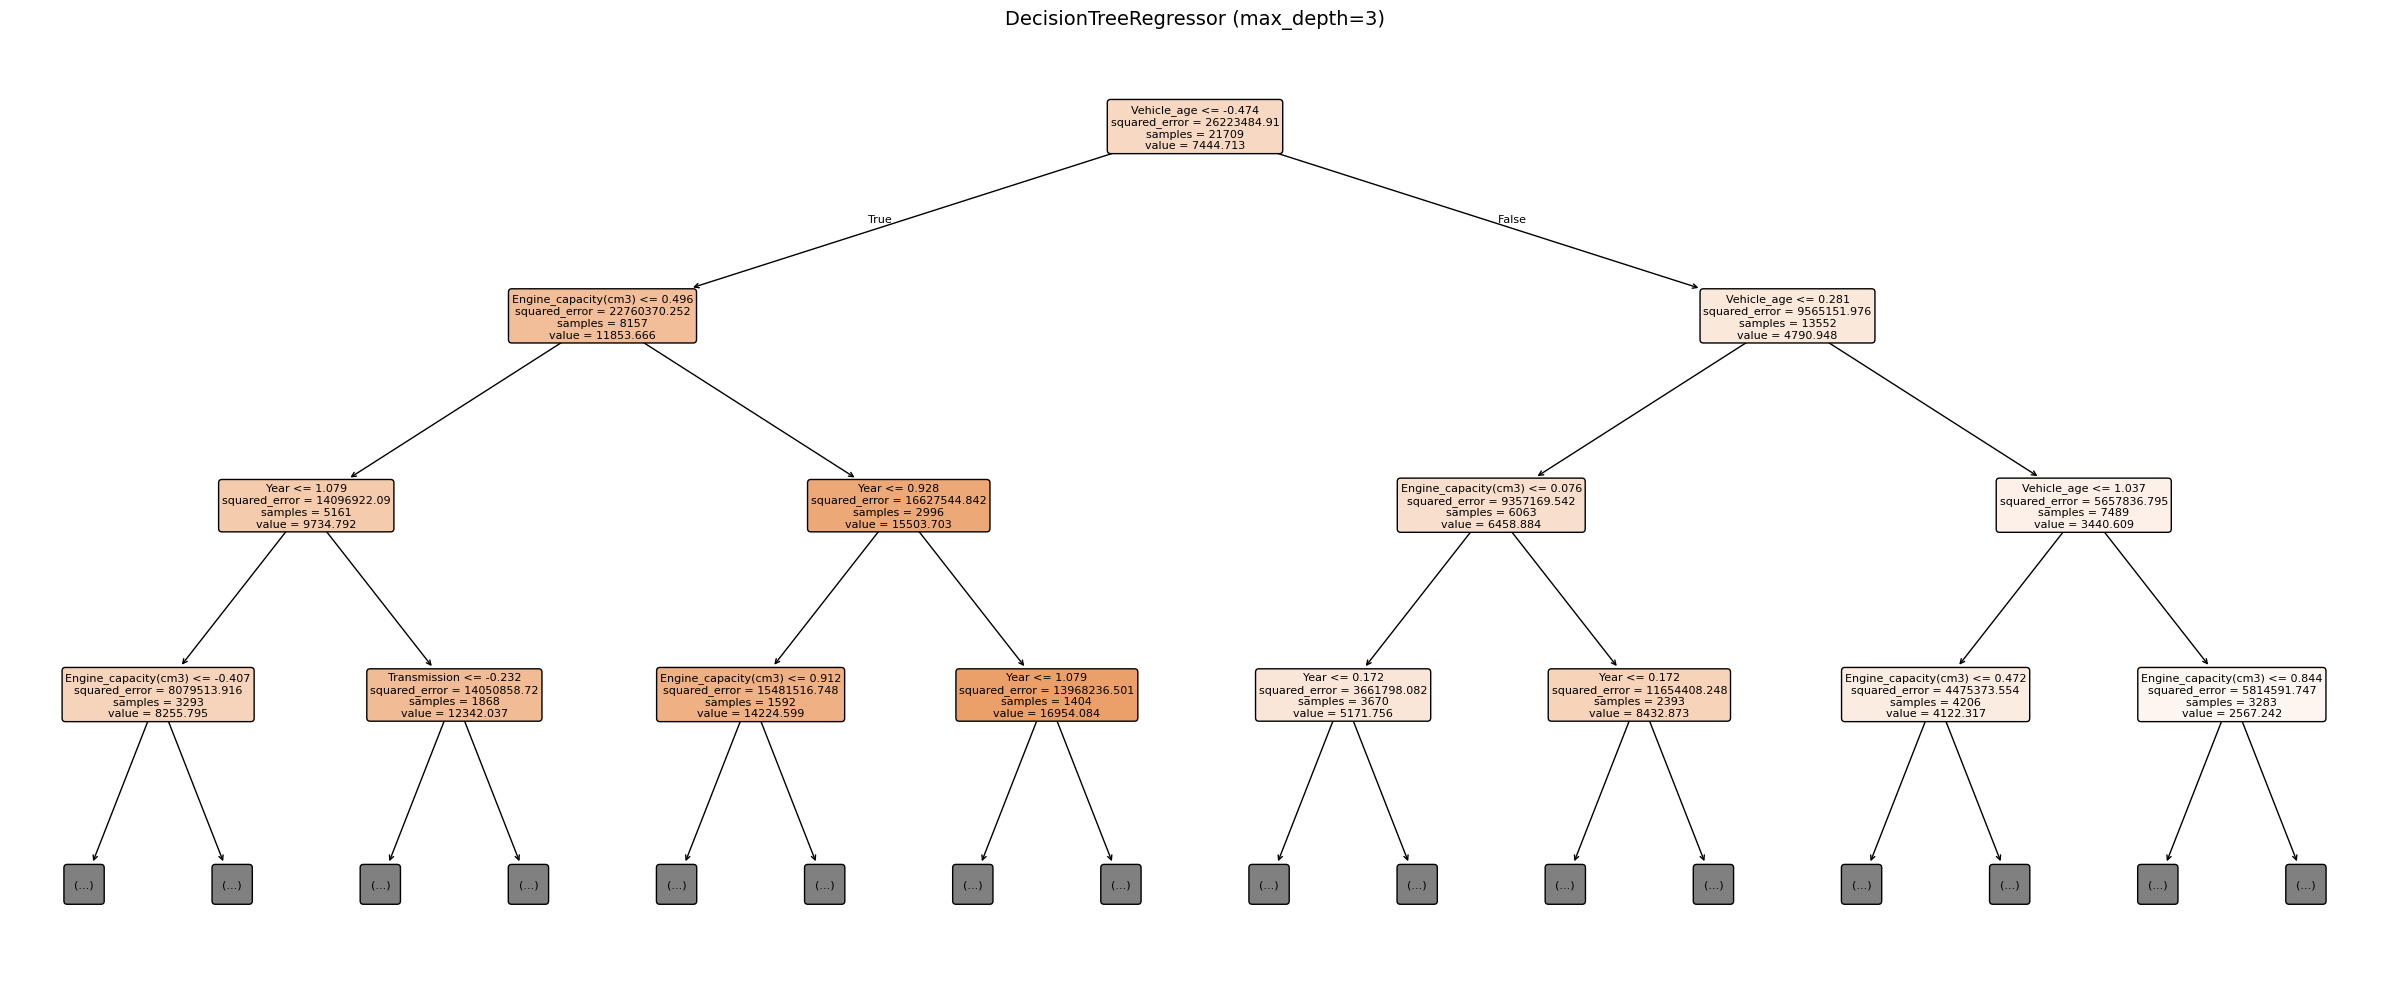

In [54]:
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    dt_r.named_steps['model'],
    feature_names=X_r.columns.tolist(),
    filled=True, rounded=True, max_depth=3, fontsize=8, ax=ax
)
plt.title('DecisionTreeRegressor (max_depth=3)', fontsize=14)
plt.tight_layout()
plt.show()

### 13.1. Правила дерева (регрессия)

In [55]:
tree_rules_r = export_text(dt_r.named_steps['model'],
                            feature_names=X_r.columns.tolist(),
                            max_depth=4)
print('Решающие правила дерева регрессии:')
print(tree_rules_r)

Решающие правила дерева регрессии:
|--- Vehicle_age <= -0.47
|   |--- Engine_capacity(cm3) <= 0.50
|   |   |--- Year <= 1.08
|   |   |   |--- Engine_capacity(cm3) <= -0.41
|   |   |   |   |--- Engine_capacity(cm3) <= -1.17
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |--- Engine_capacity(cm3) >  -1.17
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- Engine_capacity(cm3) >  -0.41
|   |   |   |   |--- Vehicle_age <= -0.93
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |--- Vehicle_age >  -0.93
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |--- Year >  1.08
|   |   |   |--- Transmission <= -0.23
|   |   |   |   |--- Engine_capacity(cm3) <= -0.67
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |--- Engine_capacity(cm3) >  -0.67
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- Transmission >  -0.23
|   |   |   |   |--- Style <= -1.23
|   |   |   |   |   |--- truncated 

## 14. Графики предсказаний vs факт (Регрессия)

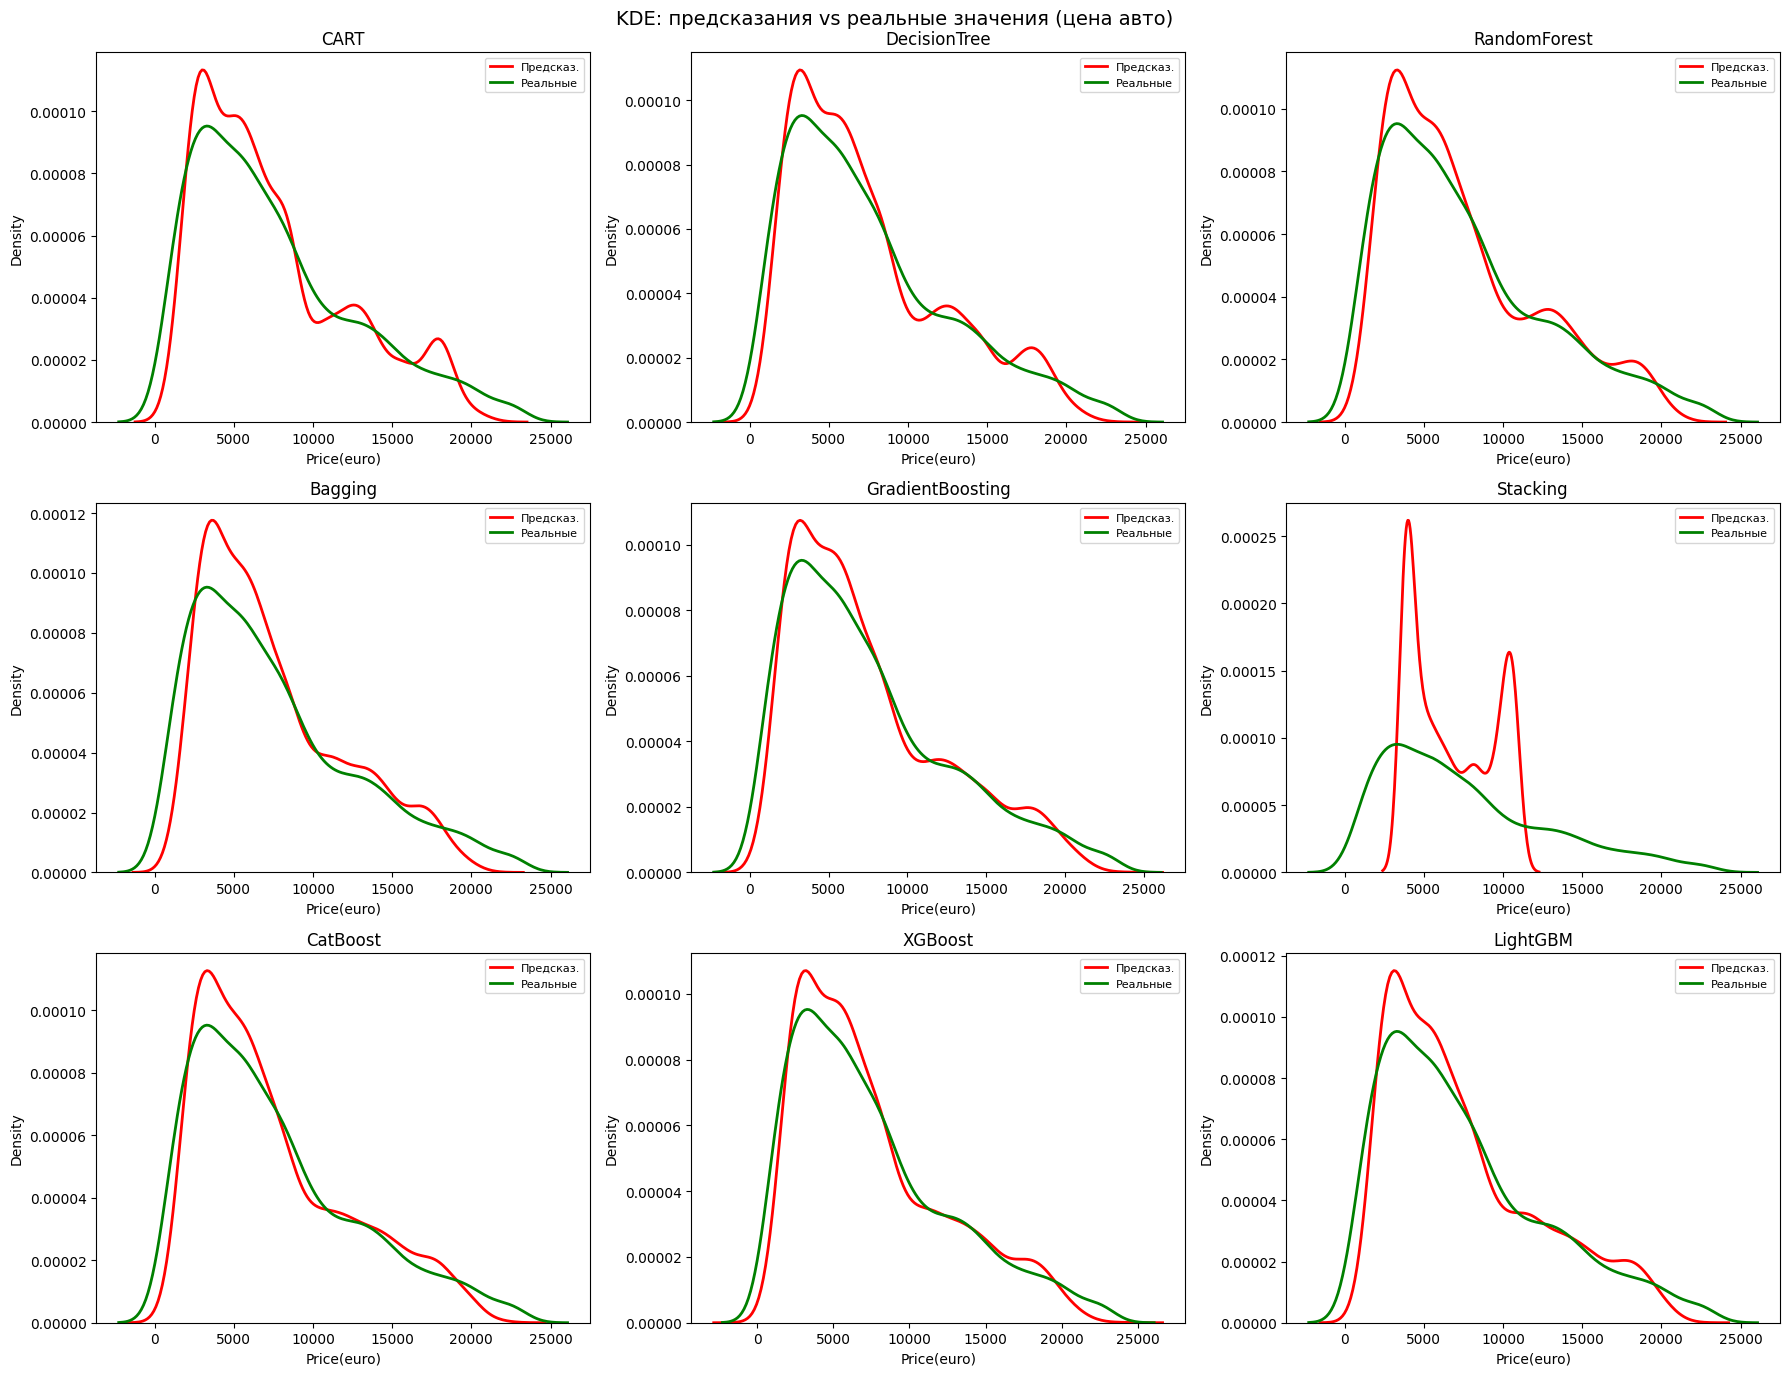

In [56]:
models_r_vis = [
    ('CART',             y_pred_cart_r),
    ('DecisionTree',     y_pred_dt_r),
    ('RandomForest',     y_pred_rf_r),
    ('Bagging',          y_pred_bag_r),
    ('GradientBoosting', y_pred_gb_r),
    ('Stacking',         y_pred_stack_r),
    ('CatBoost',         y_pred_cb_r),
    ('XGBoost',          y_pred_xgb_r),
    ('LightGBM',         y_pred_lgbm_r),
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for ax, (name, pred) in zip(axes.flat, models_r_vis):
    sns.kdeplot(pred, color='red', label='Предсказ.', linewidth=2, ax=ax)
    sns.kdeplot(y_test_r, color='green', label='Реальные', linewidth=2, ax=ax)
    ax.set_title(name)
    ax.legend(fontsize=8)
plt.suptitle('KDE: предсказания vs реальные значения (цена авто)', fontsize=14)
plt.tight_layout()
plt.show()

## 15. Таблица результатов — Регрессия

In [57]:
models_info_r = [
    ('CART (собств.)',    y_pred_cart_r),
    ('DecisionTree',     y_pred_dt_r),
    ('RandomForest',     y_pred_rf_r),
    ('Bagging',          y_pred_bag_r),
    ('GradientBoosting', y_pred_gb_r),
    ('Stacking',         y_pred_stack_r),
    ('CatBoost',         y_pred_cb_r),
    ('XGBoost',          y_pred_xgb_r),
    ('LightGBM',         y_pred_lgbm_r),
]

rows_ho_r = []
for name, pred in models_info_r:
    m = reg_metrics_dict(y_test_r, pred)
    rows_ho_r.append({'Алгоритм': name, **m})

df_ho_r = pd.DataFrame(rows_ho_r).set_index('Алгоритм')
print('=== Hold-out ===')
display(df_ho_r.round(4))

=== Hold-out ===


,MAE,MSE,RMSE,MAPE,R2
Алгоритм,,,,,
CART (собств.),1552.1227,5109797.9505,2260.4862,0.3295,0.8087
DecisionTree,1489.8886,4964438.0133,2228.1019,0.3175,0.8141
RandomForest,1259.1538,3791476.1451,1947.1713,0.2784,0.8580
Bagging,1301.1129,3758058.1550,1938.5712,0.3080,0.8593
GradientBoosting,1242.4747,3560839.5592,1887.0187,0.2786,0.8667
Stacking,2229.1956,11140051.0049,3337.6715,0.4872,0.5829
CatBoost,1285.7137,3681358.0916,1918.6866,0.2785,0.8622
XGBoost,1247.3286,3576418.5000,1891.1421,0.2740,0.8661
LightGBM,1288.0187,3692238.7828,1921.5199,0.2827,0.8618


In [58]:
cv_results_r = {
    'DecisionTree'     : cv_dt_r,
    'RandomForest'     : cv_rf_r,
    'Bagging'          : cv_bag_r,
    'GradientBoosting' : cv_gb_r,
    'Stacking'         : cv_stack_r,
    'CatBoost'         : cv_cb_r,
    'XGBoost'          : cv_xgb_r,
    'LightGBM'         : cv_lgbm_r,
}

rows_kf_r = []
for name, cv in cv_results_r.items():
    rows_kf_r.append({
        'Алгоритм': name,
        'R2'  : cv['test_r2'].mean(),
        'MAE' : -cv['test_neg_mean_absolute_error'].mean(),
    })

df_kf_r = pd.DataFrame(rows_kf_r).set_index('Алгоритм')
print('=== K-fold (mean) ===')
display(df_kf_r.round(4))

=== K-fold (mean) ===


,R2,MAE
Алгоритм,,
DecisionTree,0.8126,1491.2838
RandomForest,0.8544,1264.2456
Bagging,0.8552,1299.1351
GradientBoosting,0.8614,1244.0902
Stacking,0.5832,2226.9753
CatBoost,0.8565,1295.7000
XGBoost,0.8618,1249.0052
LightGBM,0.8576,1290.8192


In [59]:
df_ho_r_multi = df_ho_r.copy()
df_ho_r_multi.columns = pd.MultiIndex.from_product([['Hold-out'], df_ho_r.columns])

df_kf_r_multi = df_ho_r.drop(index='CART (собств.)', errors='ignore')[[]].copy()
for col in ['R2', 'MAE']:
    df_kf_r_multi[('K-fold', col)] = df_kf_r[col]

df_both_r = pd.concat([df_ho_r_multi, df_kf_r_multi], axis=1)
print('=== Сводная таблица — Регрессия (Образец 2) ===')
display(df_both_r.round(4))

=== Сводная таблица — Регрессия (Образец 2) ===


Hold-out                                       K-fold  \
                       MAE           MSE      RMSE   MAPE     R2     R2   
Алгоритм                                                                  
CART (собств.)   1552.1227  5109797.9505 2260.4862 0.3295 0.8087    NaN   
DecisionTree     1489.8886  4964438.0133 2228.1019 0.3175 0.8141 0.8126   
RandomForest     1259.1538  3791476.1451 1947.1713 0.2784 0.8580 0.8544   
Bagging          1301.1129  3758058.1550 1938.5712 0.3080 0.8593 0.8552   
GradientBoosting 1242.4747  3560839.5592 1887.0187 0.2786 0.8667 0.8614   
Stacking         2229.1956 11140051.0049 3337.6715 0.4872 0.5829 0.5832   
CatBoost         1285.7137  3681358.0916 1918.6866 0.2785 0.8622 0.8565   
XGBoost          1247.3286  3576418.5000 1891.1421 0.2740 0.8661 0.8618   
LightGBM         1288.0187  3692238.7828 1921.5199 0.2827 0.8618 0.8576   

                            
                       MAE  
Алгоритм                    
CART (собств.)         NaN  
DecisionTree     1491.2838  
RandomForest     1264.2456  
Bagging          1299.1351  
GradientBoosting 1244.0902  
Stacking         2226.9753  
CatBoost         1295.7000  
XGBoost          1249.0052  
LightGBM         1290.8192

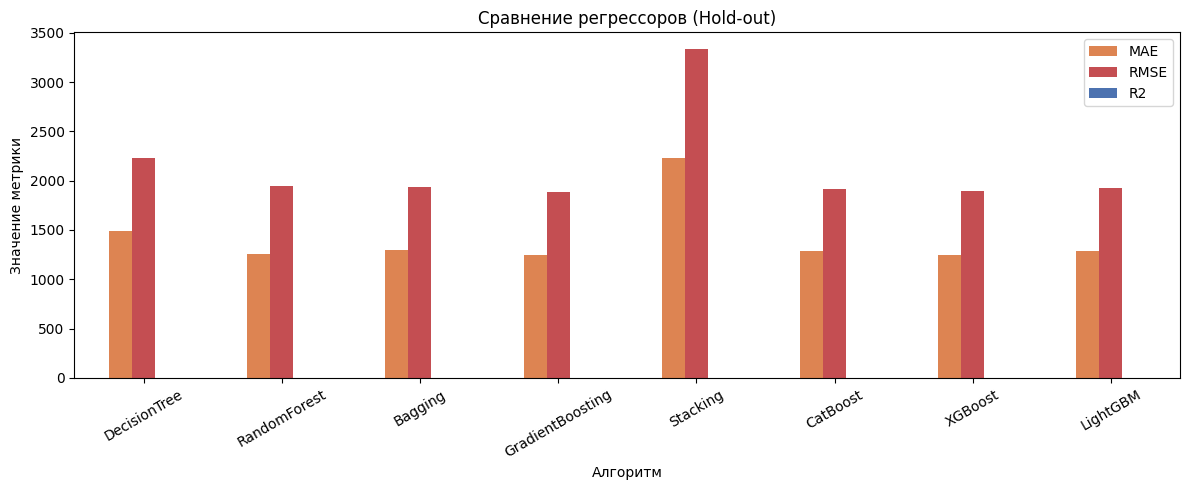

In [60]:
df_ho_r.drop(index='CART (собств.)', errors='ignore')[['MAE','RMSE','R2']].plot(
    kind='bar', figsize=(12, 5), rot=30, color=['#DD8452','#C44E52','#4C72B0']
)
plt.title('Сравнение регрессоров (Hold-out)')
plt.ylabel('Значение метрики')
plt.tight_layout()
plt.show()